<center>
    
# Using Machine Learning for Performance Management in Healthcare

## Introduction

### Case Questions
<br>

- Which **software tools** can the CFO use to embark on this ML project?
- Can we **build a ML model** to predict the patient’s satisfaction based on the other questions that are asked in the patient feedback survey?
- To what extent do the various categories and their underlying features contribute to patient satisfaction?
    - What are the **main factors** influencing patient satisfaction?
    - Given that we now know what drives patient satisfaction, can build a **performance-importance** plot to help us in identifying those services most in need of improvement?
- Can we also build this plot, taking into account individual **patient characteristics**?

In [ ]:
print("Your job:")

### CRISP-DM
<center>
<img src="https://www.dropbox.com/scl/fi/vrdehconzfgjspdgqnls3/crisp-dm.png?rlkey=fx8hanrsv2ojskusax1clxanb&raw=1" width="40%" style="float:center">

### Workflow
<center>
<img src="https://www.dropbox.com/scl/fi/k3ltvsqvtb8dxawoh4p02/python_packages.png?rlkey=iamiqr42me7x72ra5r4uwwm1q&raw=1" width="90%" style="float:center">



### Import Packages

In [ ]:
# data preprocessing
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# machine learning modelling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, accuracy_score, classification_report,\
recall_score, precision_score,confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import shap

# unsupervised machine learning
!pip install kmodes kneed
from kmodes.kmodes import KModes
from kneed import KneeLocator

import warnings
warnings.filterwarnings('ignore')

## Reading in the data

In [ ]:
%%capture
!wget -O hospital_dataset.csv 'https://drive.google.com/uc?export=download&id=1myndwZNmn1tLoXSomi54ZgzW4ftrGY5r'

df = pd.read_csv('hospital_dataset.csv')

In [ ]:
df.shape

(7845, 35)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7845 entries, 0 to 7844
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   CE_ACCESSIBILITY                7845 non-null   int64
 1   CE_VALUEFORMONEY                7845 non-null   int64
 2   EM_IMMEDIATEATTENTION           7845 non-null   int64
 3   EM_NURSING                      7845 non-null   int64
 4   EM_DOCTOR                       7845 non-null   int64
 5   EM_OVERALL                      7845 non-null   int64
 6   AD_TIME                         7845 non-null   int64
 7   AD_TARRIFFPACKAGESEXPLAINATION  7845 non-null   int64
 8   AD_STAFFATTITUDE                7845 non-null   int64
 9   INR_ROOMCLEANLINESS             7845 non-null   int64
 10  INR_ROOMPEACE                   7845 non-null   int64
 11  INR_ROOMEQUIPMENT               7845 non-null   int64
 12  INR_ROOMAMBIENCE                7845 non-null   int64
 13  FNB

## Exploratory data analysis (EDA)

### Split the dataframe

In [ ]:
df_survey = df.drop("Satisfaction", axis = 1)
# Save the target variable
df_satisfaction = df["Satisfaction"]

In [ ]:
# This dataframe only contains the answers from the survey questions
df_survey.head()

,CE_ACCESSIBILITY,CE_VALUEFORMONEY,EM_IMMEDIATEATTENTION,EM_NURSING,EM_DOCTOR,EM_OVERALL,AD_TIME,AD_TARRIFFPACKAGESEXPLAINATION,AD_STAFFATTITUDE,INR_ROOMCLEANLINESS,...,NS_CALLBELLRESPONSE,NS_NURSESATTITUDE,NS_NURSEPROACTIVENESS,NS_NURSEPATIENCE,OVS_OVERALLSTAFFATTITUDE,OVS_OVERALLSTAFFPROMPTNESS,OVS_SECURITYATTITUDE,DP_DISCHARGETIME,DP_DISCHARGEQUERIES,DP_DISCHARGEPROCESS
0,3,2,3,3,3,3,4,4,4,2,...,3,3,3,3,3,3,3,3,3,3
1,3,4,3,3,4,3,1,1,2,3,...,1,4,3,3,3,3,3,3,3,1
2,3,3,3,3,3,3,3,2,2,2,...,2,3,3,3,3,3,3,3,3,3
3,4,2,3,4,3,3,1,2,1,4,...,2,4,3,4,3,3,3,1,2,2
4,3,3,4,4,4,4,3,3,3,3,...,3,3,3,3,3,3,2,3,3,3


In [ ]:
# This dataframe only contains the target variable a.k.a. the patient satisfaction
df_satisfaction.head()

0    0
1    1
2    1
3    1
4    0
Name: Satisfaction, dtype: int64

### Target variable: Relative Count

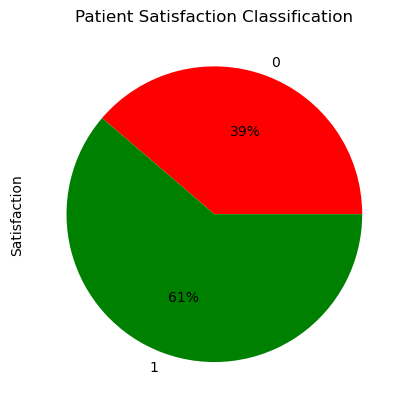

In [ ]:
# Plot this in a piechart
df.groupby(df.Satisfaction).size()\
    .plot(kind='pie', autopct='%1.0f%%', colors=["red", "green"])\
    .set_ylabel('Satisfaction')
plt.title('Patient Satisfaction Classification');

### Explore the survey answers  

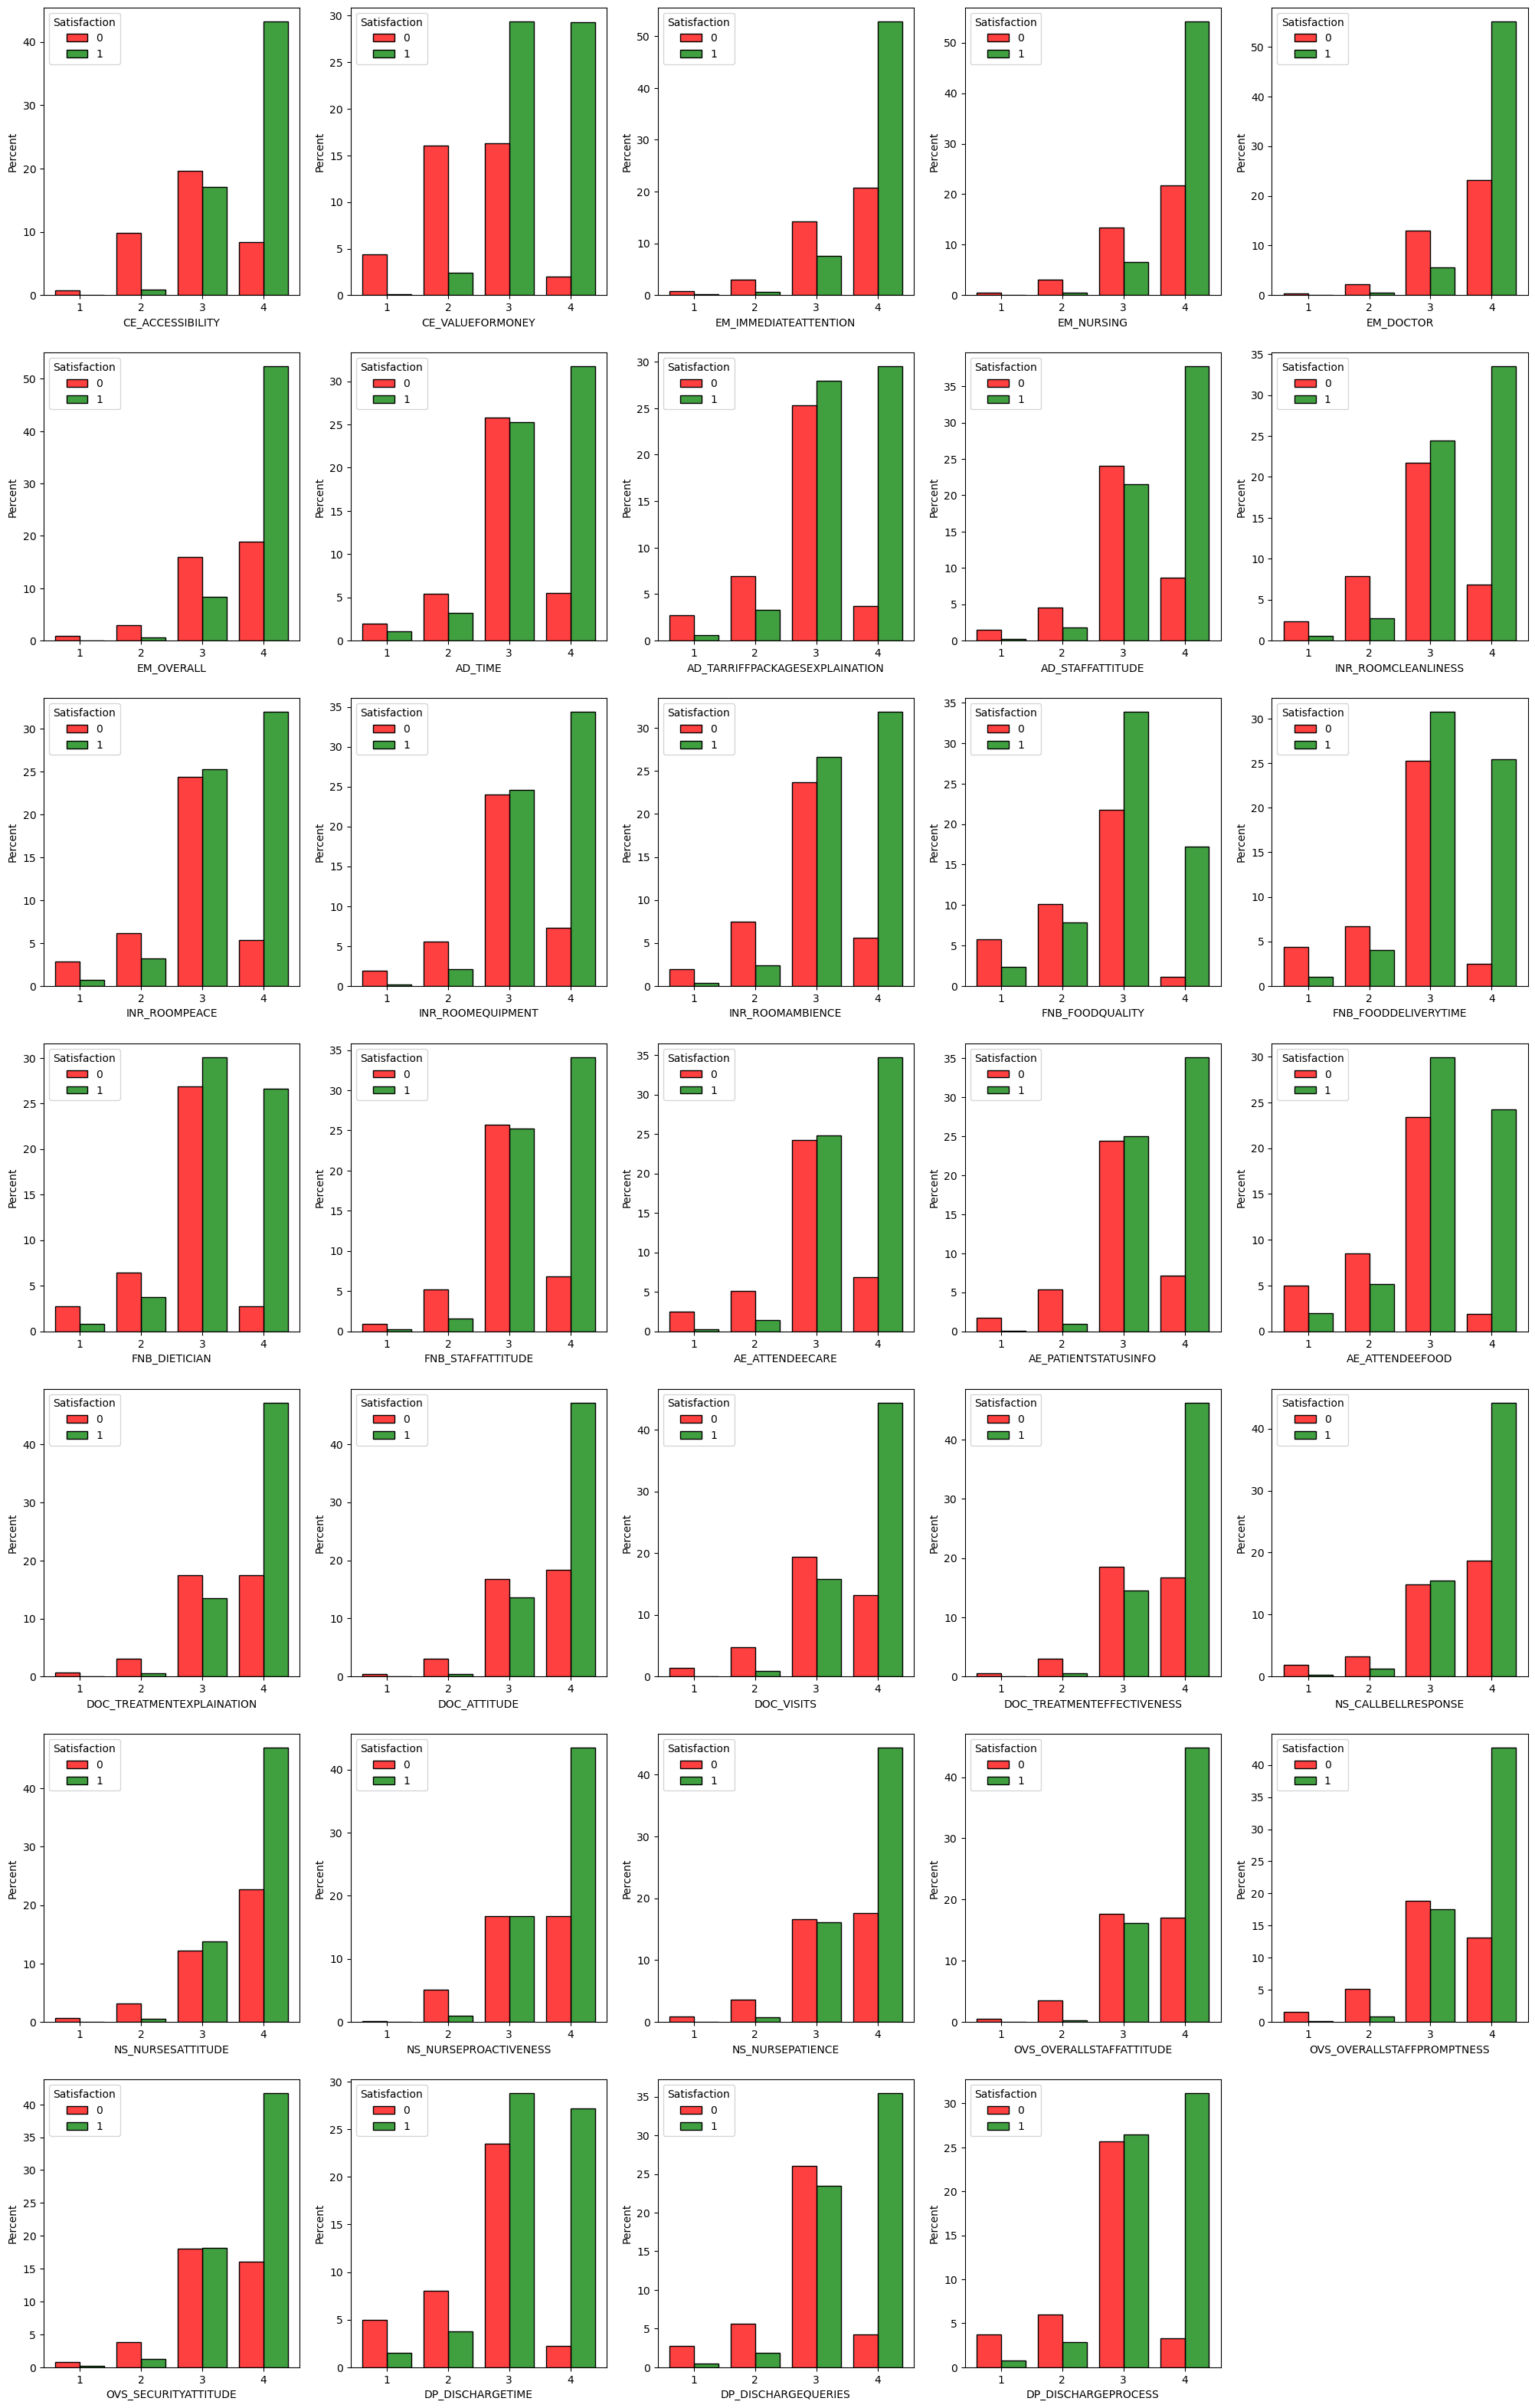

In [ ]:
fig = plt.figure(figsize=(25,40))

for i, col in enumerate(df.columns.drop("Satisfaction")):
    plt.subplot(7, 5, i+1)
    sns.histplot(x=df[col], hue=df.Satisfaction, palette={0: "red", 1:"green"},
                 stat="percent", multiple="dodge", discrete=True, shrink=0.8, common_norm=True)

- `stat="percent"`: specify percentages instead of absolute counts. This is a recent feature, so make sure you have the updated seaborn package. Otherwise run the following: pip install --upgrade seaborn
- `multiple="dodge"`: display columns next to each other, instead on top of each other
- `discrete=True`: values are discrete
- `shrink=0.8`: shrink columns so different levels don't touch each other (otherwise continuous graph for the different values)
- `common_norm`=False: normalize per group and not the entire dataset

Look at Value for Money and Discharge Process. What do you notice and how will it affect the predictions?



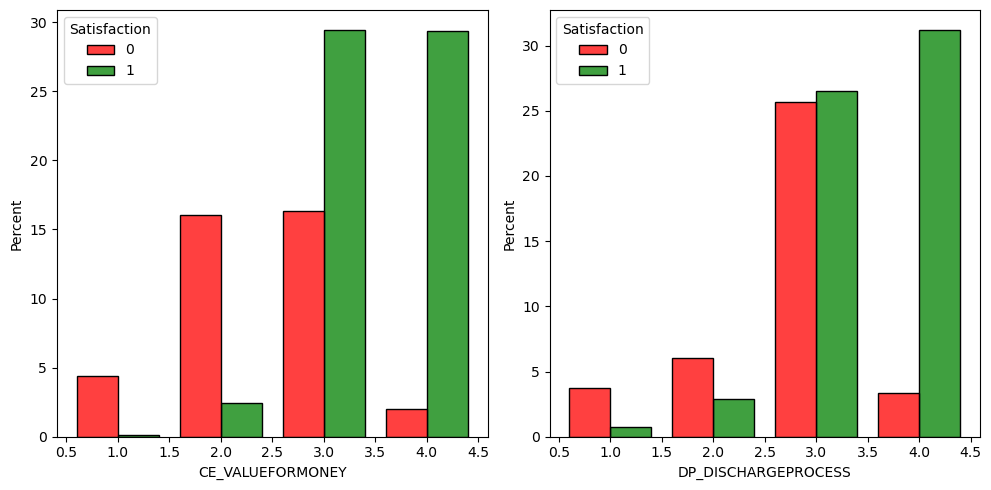

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

sns.histplot(x=df["CE_VALUEFORMONEY"], hue=df.Satisfaction, palette={0: "red", 1:"green"},
             stat="percent", multiple="dodge", discrete=True, shrink=0.8, common_norm=True, ax=axs[0])

sns.histplot(x=df["DP_DISCHARGEPROCESS"], hue=df.Satisfaction, palette={0: "red", 1:"green"},
             stat="percent", multiple="dodge", discrete=True, shrink=0.8, common_norm=True, ax=axs[1])

plt.tight_layout()
plt.show()

## Predictive modeling

### Defining our train and test set
<br>

- Train Dataset: used to fit the machine learning model.
- Test Dataset: used to evaluate the fit of the machine learning model and its subsequent predictions.

<br>

<center>
<img src="https://www.dropbox.com/scl/fi/kllhvxeb663p2k3g62xev/train_test_split.png?rlkey=6rgl60olwwlewackqw28xhbmc&raw=1" width="70%" style="float:center">


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df_survey, df_satisfaction, test_size=0.2, random_state=42)

In [ ]:
print(X_train.shape)

(6276, 34)


In [ ]:
y_train.value_counts(normalize=True)

Satisfaction
1    0.613129
0    0.386871
Name: proportion, dtype: float64

### Explainable AI
<center>
<img src="https://www.dropbox.com/scl/fi/13jins7hx8vamlaf5rwhy/Explainable-AI.png?rlkey=zj2lcnatthwdiy1u4x7b6ckp0&raw=1" width="90%" style="float:center">
    


### Logistic regression
<center>
<img src="https://www.dropbox.com/scl/fi/ci7lxdsvm2ceo6f41jbgz/Logistic-regression.png?rlkey=hlru34ou4w6d8ndxph9w4zrq4&raw=1" width="90%" style="float:center">

In [ ]:
# Define a logistic regression classifier
lr_model = LogisticRegression(random_state = 42)
# Fit the classifier on the training data
lr_model = lr_model.fit(X_train, y_train)
y_pred= lr_model.predict(X_test)


# Estimate the accuracy of the classifier on both training and test data
print('Accuracy of LR classifier on overall sample training set: {:.2f}'
     .format(lr_model.score(X_train, y_train)))
print('Accuracy of LR classifier on overall sample test set: {:.2f}\n'
     .format(lr_model.score(X_test, y_test)))

Accuracy of LR classifier on overall sample training set: 0.83
Accuracy of LR classifier on overall sample test set: 0.82



### Performance of the model

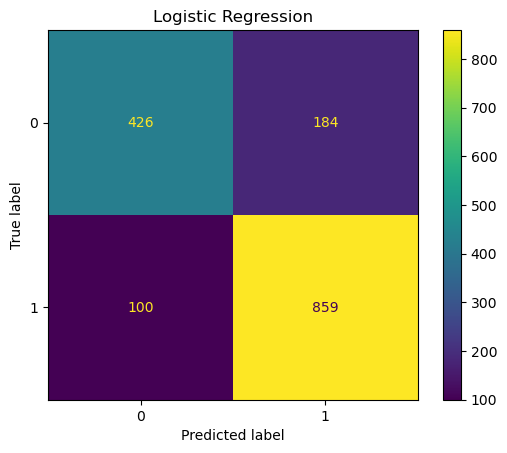

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_model.classes_)
disp.plot()
plt.title('Logistic Regression');

Are we happy with this result?

- **accuracy**: $\frac{tp+tn}{tp+tn+fp+fn}$
    - proportion of correctly classified instances
    
<br>

- **precision**: $\frac{tp}{tp+fp}$
    - proportion of predicted instances that truly belongs to that class
    
<br>

- **recall**: $\frac{tp}{tp+fn}$
    - proportion of actual instances of a class correctly classified


#### Classification report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.70      0.75       610
           1       0.82      0.90      0.86       959

    accuracy                           0.82      1569
   macro avg       0.82      0.80      0.81      1569
weighted avg       0.82      0.82      0.82      1569



## Feature importance: Key drivers of patient satisfaction

How do you interpret the following coefficients?

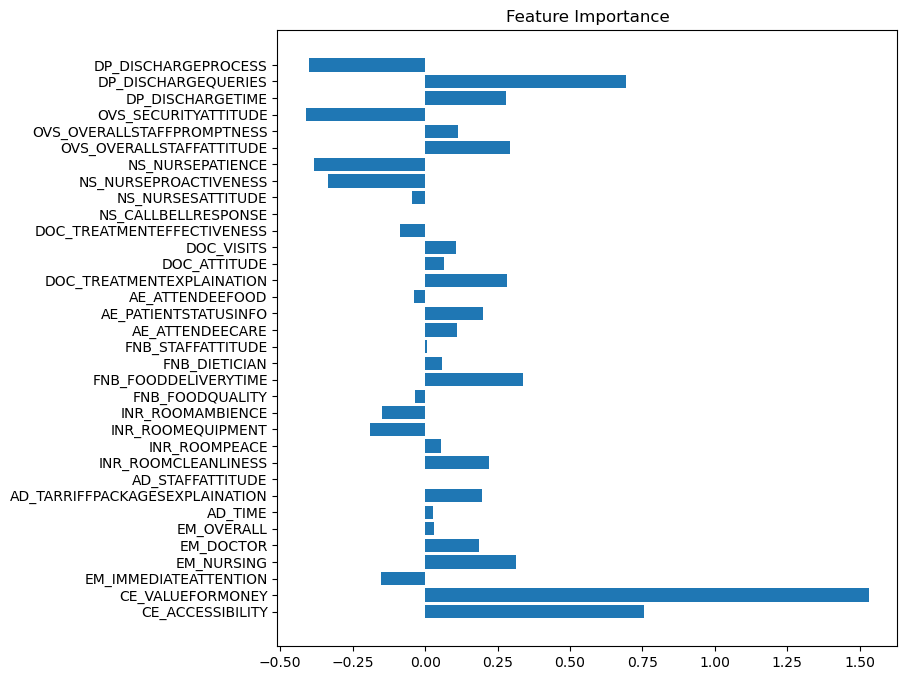

In [ ]:
importance = pd.Series(lr_model.coef_[0], index=X_train.columns)

fig = plt.figure(figsize = (8,8))
plt.barh(X_train.columns, importance)
plt.title('Feature Importance')
plt.show()

## Ensemble models

###### Logistic regression
    
&#43; Easy to implement<br>
&#43; High interpretation<br>
&#8722; Lower performance<br>
&#8722; Linear boundary

<center><img src="https://www.dropbox.com/s/nfl722ylatv9sgo/LR_boundary.png?raw=1" width="70%" style="float:right"></center>

###### Decision tree
    
&#43; More interpretable<br>
&#43; Feature importance<br>
&#8722; Lower performance<br>
&#8722; Overfitting

<center><img src="https://www.dropbox.com/s/xdvmykwwnkt1bk3/DT_boundary.png?raw=1" width="70%" style="float:right"></center>

### Logistic Regression vs Random Forest
<br>

<left>
<img src="https://www.dropbox.com/scl/fi/viqzaerfrge7hiqohc9jt/logistic-vs-random-forest.png?rlkey=bryllwey8eqomhrhcsjgjvnkq&raw=1" width="50%" style="float:left">
  
<br>
    <br>
<right>
<img src="https://www.dropbox.com/scl/fi/a7ildp1qp7ylbd7bkgjrj/random-forest-classifier.jpg?rlkey=mh471ihmo49x84s3vhn6ti513&raw=1" width="50%" style="float:right">

### Fit Random Forest Classifier

In [ ]:
# Create a Random Forest classifier
rf_model = RandomForestClassifier(random_state=42)
# Fit the classifier on the training data
rf_model.fit(X_train, y_train)
# Make predictions on the test set
y_pred= rf_model.predict(X_test)

# Estimate the accuracy of the classifier on both training and test data
print('Accuracy of LR classifier on overall sample training set: {:.2f}'
     .format(rf_model.score(X_train, y_train)))
print('Accuracy of LR classifier on overall sample test set: {:.2f}\n'
     .format(rf_model.score(X_test, y_test)))

# Evaluate the performance
print(classification_report(y_test, y_pred))

Accuracy of LR classifier on overall sample training set: 0.98
Accuracy of LR classifier on overall sample test set: 0.93

              precision    recall  f1-score   support

           0       0.91      0.92      0.91       610
           1       0.95      0.94      0.94       959

    accuracy                           0.93      1569
   macro avg       0.93      0.93      0.93      1569
weighted avg       0.93      0.93      0.93      1569



#### Grid Search

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Create a RandomForestClassifier instance
rf_model = RandomForestClassifier(random_state = 42)

# Define the parameter grid to search over
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_depth': [10, 20, 30],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4],    # Minimum number of samples required to be at a leaf node
    'bootstrap': [True, False]        # Whether bootstrap samples are used when building trees
}

# Create a GridSearchCV instance
grid_search = GridSearchCV(estimator=rf_model,
                           param_grid=param_grid,
                           cv=5, # Perform a 5-fold cross-validation
                           verbose=2, # Print the output
                           n_jobs=-1) # Uses all available cores for faster computation

# Fit the grid search model on your training data (X_train, y_train)
grid_search.fit(X_train, y_train)

best_rf_model = grid_search.best_estimator_

y_pred= best_rf_model.predict(X_test)

# Print the best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)


Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best Parameters: {'bootstrap': False, 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best Score: 0.9279799274240617


In [ ]:
# Estimate the accuracy of the classifier on both training and test data
print('Accuracy of LR classifier on overall sample training set: {:.2f}'
     .format(best_rf_model.score(X_train, y_train)))
print('Accuracy of LR classifier on overall sample test set: {:.2f}\n'
     .format(best_rf_model.score(X_test, y_test)))

Accuracy of LR classifier on overall sample training set: 0.98
Accuracy of LR classifier on overall sample test set: 0.94



In [ ]:
# Evaluate the performance
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92       610
           1       0.95      0.95      0.95       959

    accuracy                           0.94      1569
   macro avg       0.94      0.94      0.94      1569
weighted avg       0.94      0.94      0.94      1569



### SHAP values

- Global interpretability: Shows whether feature has positive or negative impact on predictions
- Local interpretability: Can be calculated for each individual prediction
- Versatility: Can be used to explain a larger variety of models

- SHAP quantifies how important each input variable (aka “feature”) is to a model for making predictions
    - F(x) = base value + sum (Shap values)
- Typically depicted as **beeswarm** plots:

<br>

<center>
<img src="https://www.dropbox.com/scl/fi/1t66vch3e5rbd7anfo9e8/shap-values-example.jpg?rlkey=9s26e8wtniqvfzt3njq3ko2lk&raw=1" width="80%" style="float:center">

### Exercise 1

Using the Random Forest classifier we just built and the SHAP library, create a SHAP explainer for your model and compute SHAP values on the test set. For a binary classification problem, extract the SHAP values corresponding to the positive class. Plot a summary of the SHAP values to interpret which features most influence the model predictions.


In [ ]:
import shap
# Apply SHAP on the best model
explainer = shap.Explainer(best_rf_model)
shap_values = explainer.shap_values(X_test)
shap_values # Each SHAP value represents how much each feature contributes to the output of the row's prediction

array([[[-0.03636105,  0.03636105],
        [-0.06393479,  0.06393479],
        [-0.00134002,  0.00134002],
        ...,
        [-0.02477463,  0.02477463],
        [-0.03599077,  0.03599077],
        [-0.02184092,  0.02184092]],

       [[ 0.03973461, -0.03973461],
        [ 0.1522395 , -0.1522395 ],
        [-0.01890524,  0.01890524],
        ...,
        [ 0.0192948 , -0.0192948 ],
        [ 0.05552047, -0.05552047],
        [ 0.03218413, -0.03218413]],

       [[-0.03754463,  0.03754463],
        [-0.00457137,  0.00457137],
        [-0.00143626,  0.00143626],
        ...,
        [-0.05269816,  0.05269816],
        [-0.05612659,  0.05612659],
        [-0.07121857,  0.07121857]],

       ...,

       [[-0.06265469,  0.06265469],
        [-0.04476175,  0.04476175],
        [-0.00100418,  0.00100418],
        ...,
        [ 0.04916839, -0.04916839],
        [ 0.04851252, -0.04851252],
        [ 0.02686862, -0.02686862]],

       [[ 0.1565751 , -0.1565751 ],
        [ 0.22643034, -0.22

In [ ]:
# For Random Forest, you need to manually extract the SHAP values for the positive class
shap_values_class_1 = shap_values[:, :, 1]
shap_values_class_1

array([[ 0.03636105,  0.06393479,  0.00134002, ...,  0.02477463,
         0.03599077,  0.02184092],
       [-0.03973461, -0.1522395 ,  0.01890524, ..., -0.0192948 ,
        -0.05552047, -0.03218413],
       [ 0.03754463,  0.00457137,  0.00143626, ...,  0.05269816,
         0.05612659,  0.07121857],
       ...,
       [ 0.06265469,  0.04476175,  0.00100418, ..., -0.04916839,
        -0.04851252, -0.02686862],
       [-0.1565751 , -0.22643034, -0.00282271, ..., -0.01607445,
        -0.04208653, -0.02736283],
       [ 0.03545027,  0.06082174,  0.00345085, ...,  0.03185948,
         0.04598802,  0.03170847]])

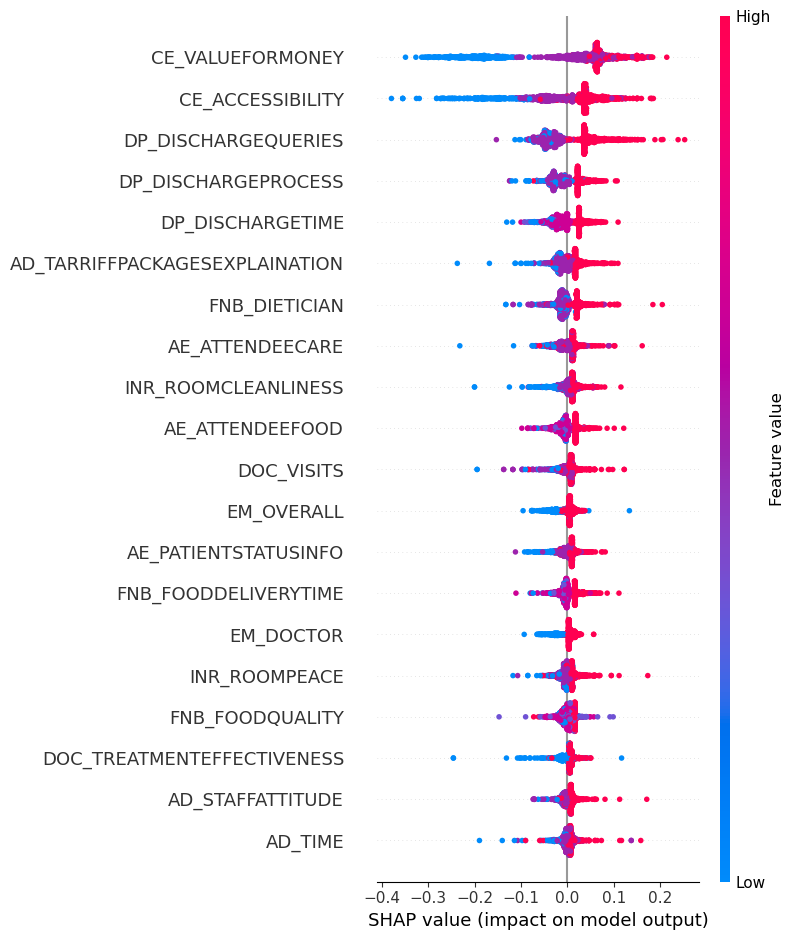

In [ ]:
shap.summary_plot(shap_values_class_1, X_test)


### Exercise 2

Fit a Decision Tree Classifier on the data and print the classification report. To what extent do the results differ from the Random Forest Classifier?


In [ ]:
# Create a decision tree classifier
dt_model = DecisionTreeClassifier(random_state = 42)
# Fit the classifier on the training data
dt_model = dt_model.fit(X_train,y_train)
y_pred = dt_model.predict(X_test)

# Estimate the accuracy of the classifier on both training and test data
print('Accuracy of LR classifier on overall sample training set: {:.2f}'
     .format(dt_model.score(X_train, y_train)))
print('Accuracy of LR classifier on overall sample test set: {:.2f}\n'
     .format(dt_model.score(X_test, y_test)))

# Evaluate the performance
print(classification_report(y_test, y_pred))


### Importance - Performance plot

In [ ]:
# For Random Forest, you need to manually extract the SHAP values for the positive class
# Calculate the mean absolute SHAP values for each feature
feature_importance = np.mean(np.abs(shap_values_class_1), axis=0)

# Optionally, sort the features by importance
sorted_idx = np.argsort(feature_importance)[::-1]
sorted_importance = feature_importance[sorted_idx]
sorted_features = X_test.columns[sorted_idx]

feature_importance = pd.DataFrame(feature_importance)
feature_importance.index = X_train.columns
feature_importance

# Display the results
for feature, importance in zip(sorted_features, sorted_importance):
    print(f"{feature}: {importance:.4f}")


In [ ]:
# Function to compute feature-wise performance
def performance(df, features):
    return pd.Series({feature: df[feature].mean() for feature in features})


def category_performance(df, features):
    list_perf = []

    for feature in features:
        # Compute the mean for each feature column
        # (Assuming df[feature] is numeric)
        list_perf.append(df[feature].mean())

    return list_perf

# Compute the performance for each feature in sorted order
performance = category_performance(X_train, sorted_features)

# Create a pandas Series where the index is the feature name
performance_series = pd.Series(performance, index=sorted_features)
performance_series

In [ ]:
# Concatenate both series into one DataFrame
ip = pd.concat([feature_importance, performance_series], axis=1, keys=["importance", "performance"])
ip.columns = ["importance", "performance"]
print(ip)

# Filter out unwanted features from the ip DataFrame
features_to_remove = ["CE_VALUEFORMONEY", "CE_ACCESSIBILITY"]
ip = ip[~ip.index.isin(features_to_remove)]
print("\nAfter filtering:")
print(ip)

In [ ]:
plt.figure(figsize=(15,10))
plt.xlabel('Performance')
plt.ylabel('Importance')
plt.scatter(ip.performance, ip.importance);

# Label the datapoints
for i in range(len(ip)):
    plt.annotate(ip.index[i], (ip.performance[i]+.02, ip.importance[i]), fontsize=12)

plt.axhline(y= ip.importance.mean(), color='r', linestyle='-')
# Vertical line is the mean of the performance
plt.axvline(x= ip.performance.mean(), color='r', linestyle='-')

# Add the label for each quadrant
plt.annotate("Low Importance", (min(ip.performance), min(ip.importance)), color = 'r', fontsize = 12)
plt.annotate("Improve", (min(ip.performance), max(ip.importance)), color = 'r', fontsize = 12)
plt.annotate("Leverage", (max(ip.performance)-0.05, max(ip.importance)), color = 'r', fontsize = 12)
plt.annotate("Maintain", (max(ip.performance)-0.05, min(ip.importance)), color = 'r', fontsize = 12)
plt.show()

## Part 3 - Clustering

### Clustering based on background

Check which features we will use and what their data type is:

In [ ]:
df = pd.read_csv('data/hospital_dataset_background.csv')
df.head() # We take a look at the first 5 rows of the dataset


,SN,MaritalStatus,AgeYrs,Gender,BedCategory,Department,Estimatedcost,CE_ACCESSIBILITY,CE_VALUEFORMONEY,EM_IMMEDIATEATTENTION,...,OVS_OVERALLSTAFFATTITUDE,OVS_OVERALLSTAFFPROMPTNESS,OVS_SECURITYATTITUDE,DP_DISCHARGETIME,DP_DISCHARGEQUERIES,DP_DISCHARGEPROCESS,AdmissionDate,DischargeDate,LengthofStay,Satisfaction
0,1,Single,4.0,F,SPECIAL,PEDIATRIC,25000.0,4,4,4,...,4,4,4,4,4,4,18/07/2014,21/07/2014,3,1
1,2,Single,13.0,F,SPECIAL,PEDIATRIC,15000.0,4,4,4,...,4,4,4,4,4,4,11/07/2014,16/07/2014,5,1
2,3,Married,33.0,F,SEMISPECIAL,GYNAEC,70000.0,3,2,4,...,4,4,4,3,4,3,17/06/2014,20/07/2014,33,1
3,4,Married,51.0,F,SPECIAL,GYNAEC,150000.0,4,3,4,...,4,3,3,3,4,3,16/07/2014,22/07/2014,6,1
4,5,Married,31.0,F,SPECIAL,GYNAEC,100000.0,4,4,4,...,4,4,4,4,4,4,13/07/2014,16/07/2014,3,1


In [ ]:
df_background = df[['MaritalStatus','AgeYrs', 'Gender','BedCategory','Department', 'Estimatedcost']]
df_background.dtypes

MaritalStatus     object
AgeYrs           float64
Gender            object
BedCategory       object
Department        object
Estimatedcost    float64
dtype: object

We will only use the following variables:
- AgeYrs
- Gender
- Department


But feel free to play around and include the other ones too!

In [ ]:
# Create a new dataframe df_clus for the chosen background variables
df_clus = df_background[["Gender", "Department", "AgeYrs"]].copy()
df_clus.head()

,Gender,Department,AgeYrs
0,F,PEDIATRIC,4.0
1,F,PEDIATRIC,13.0
2,F,GYNAEC,33.0
3,F,GYNAEC,51.0
4,F,GYNAEC,31.0


#### Kmeans
<br>

- Clustering on **numerical variables**
- Based on distance between the data points

#### Kmodes
<br>

- Clustering on **categorical variables**
- Based on dissimilarities between the data points

In [ ]:
bins = pd.IntervalIndex.from_tuples([(0, 18), (18, 24), (24, 34), (34, 44),
                                     (44, 54), (54, 64), (64, 100)])
df_clus.AgeYrs = pd.cut(df_clus.AgeYrs, bins)
df_clus.head()

,Gender,Department,AgeYrs
0,F,PEDIATRIC,"(0, 18]"
1,F,PEDIATRIC,"(0, 18]"
2,F,GYNAEC,"(24, 34]"
3,F,GYNAEC,"(44, 54]"
4,F,GYNAEC,"(24, 34]"


#### Find the optimal number of clusters (K)
<br>

- Step 1: Calculate the cost for several values of K
    - Cost is the sum of all the dissimilarities between the clusters
    - Cost goes down as number of clusters increases

In [ ]:
cost = []
K = range(1,10)
for num_clusters in list(K):
    kmode = KModes(n_clusters=num_clusters, verbose=False)
    kmode.fit_predict(df_clus)
    cost.append(kmode.cost_)

- Step 2: Optimal value of K is at the "elbow"
    - Where the decrease in cost becomes smaller

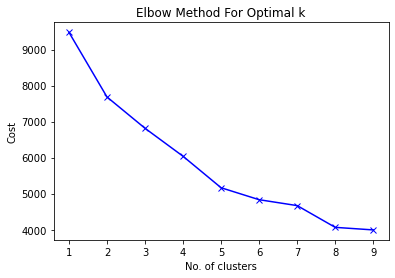

In [ ]:
plt.plot(K, cost, 'bx-')
plt.xlabel('No. of clusters')
plt.ylabel('Cost')
plt.title('Elbow Method For Optimal k')
plt.show()

You can visually determine where the "elbow" is or use a package to find it

In [ ]:
kl = KneeLocator(range(1, 10), cost,
            curve="convex",
            direction="decreasing")
kl.elbow

5

#### Build the clusters

In [ ]:
kmode = KModes(n_clusters=kl.elbow, init = "Huang", random_state= 0, verbose=False)
clusters = kmode.fit_predict(df_clus)

How many instances are there in each cluster?

In [ ]:
unique, counts = np.unique(kmode.labels_, return_counts=True)
dict(zip(unique, counts))

{0: 2387, 1: 876, 2: 921, 3: 421, 4: 748}


Let's create a new column with the cluster labels in

In [ ]:
df_clus["Cluster"] = clusters
df_clus.head()

,Gender,Department,AgeYrs,Cluster
0,F,PEDIATRIC,"(0, 18]",4
1,F,PEDIATRIC,"(0, 18]",4
2,F,GYNAEC,"(24, 34]",0
3,F,GYNAEC,"(44, 54]",0
4,F,GYNAEC,"(24, 34]",0


#### What are the characteristics of each cluster?

In [ ]:
df_clus.groupby(['Cluster']).agg(pd.Series.mode)

,Gender,Department,AgeYrs
Cluster,,,
0,F,GEN,"(24, 34]"
1,M,SPECIAL,"(54, 64]"
2,M,GEN,"(34, 44]"
3,M,SPECIAL,"(64, 100]"
4,M,PEDIATRIC,"(0, 18]"


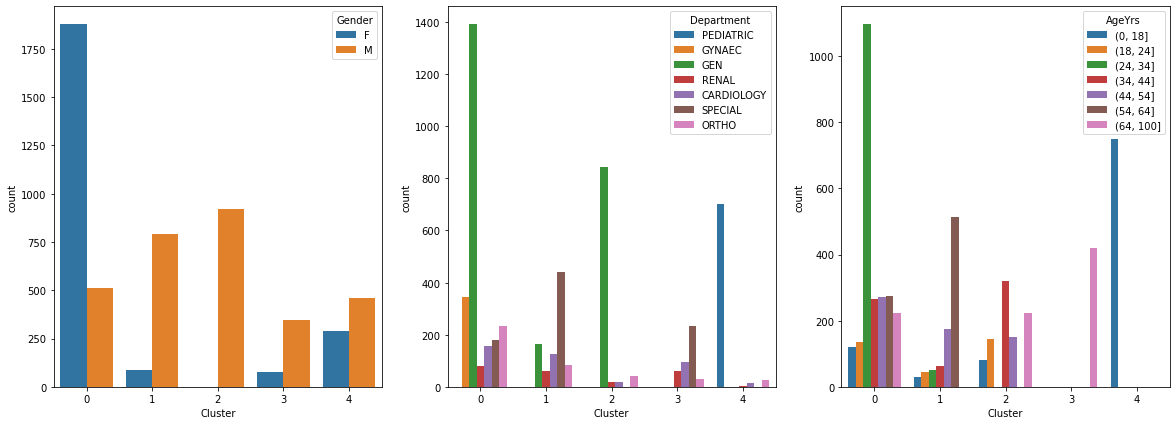

In [ ]:
fig = plt.figure(figsize=(20,7))

for i, col in enumerate(['Gender', 'Department', 'AgeYrs']):
    plt.subplot(1, 3, i+1)
    sns.countplot(x= "Cluster",hue = col, data = df_clus)

### Important Features per Patient

<center> <a href="https://hospitaldashb.herokuapp.com/">Dashboard</a> </center>

<video
       src="https://www.dropbox.com/scl/fi/93xwlgtzhakyqv41nfqjj/dashboard_hospitalcase.mp4?rlkey=nozwjc3jlnt5l4xqdn647p8zb&raw=1"  
       controls width=100%>  
</video>


This is a python notebook authored by Emma Willems and Carl-Erik Heyvaert under the close supervision of Prof Dr Kristof Stouthuysen.

All authors and supervisors are members of the **Centre for Financial Leadership & Digital Transformation** at **Vlerick Business School**.
Contact information: carlerik.heyvaert@vlerick.com and kristof.stouthuysen@vlerick.com